In [1]:
import os

# Dossier actuel
print("📁 Dossier actuel :", os.getcwd())

# Parcourir tout le dossier du projet
print("\n=== RECHERCHE DU FICHIER credit_data_clean.csv ===")
for root, dirs, files in os.walk('..'):
    for file in files:
        if 'credit_data_clean' in file:
            print(f"✅ Trouvé : {os.path.join(root, file)}")

📁 Dossier actuel : C:\Users\idris\OneDrive\Desktop\AI-Credit-Risk-Platform\notebooks

=== RECHERCHE DU FICHIER credit_data_clean.csv ===
✅ Trouvé : ..\notebooks\data\processed\credit_data_clean.csv


In [2]:
import os
print(os.path.exists('data/processed/credit_data_clean.csv'))  # True

True


 Dataset déjà présent : data/raw/default_of_credit_card_clients.xls
 Dataset chargé : 30000 lignes, 25 colonnes
✅ Colonnes renommées

=== TYPES DES COLONNES ===
LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
default      int64
dtype: object

=== STATISTIQUES DESCRIPTIVES ===
            LIMIT_BAL           SEX     EDUCATION      MARRIAGE           AGE  \
count    30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean    167484.322667      1.603733      1.853133      1.551867     35.485500   
std     129747.661567      0.489129      0.790349      0.521970      9.217904   
min      1

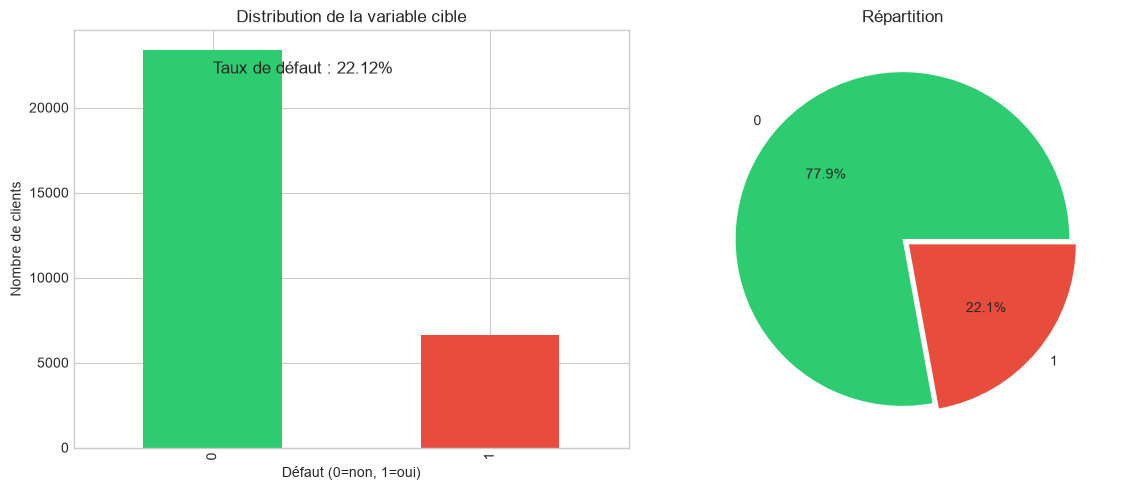

✅ Data Dictionary sauvegardé !
✅ Données nettoyées sauvegardées dans 'data/processed/credit_data_clean.csv'
Shape final : (30000, 24)


In [1]:
# %% [markdown]
# # 01 - Data Understanding
# ## Projet : AI Credit Risk Prediction Platform
# ## Dataset : UCI Default of Credit Card Clients

# %% [markdown]
# ### 1. Import des librairies

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

# %% [markdown]
# ### 2. Téléchargement du dataset (si pas déjà fait)

# %%
import urllib.request
import os

# Télécharger le dataset
def download_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
    output_path = "data/raw/default_of_credit_card_clients.xls"
    
    os.makedirs("data/raw", exist_ok=True)
    if not os.path.exists(output_path):
        print("Téléchargement du dataset UCI...")
        urllib.request.urlretrieve(url, output_path)
        print(f" Dataset téléchargé : {output_path}")
    else:
        print(f" Dataset déjà présent : {output_path}")

download_dataset()

# %% [markdown]
# ### 3. Chargement des données

# %%
file_path = 'data/raw/default_of_credit_card_clients.xls'
df = pd.read_excel(file_path, header=1)
print(f" Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

# %% [markdown]
# ### 4. Nettoyage initial

# %%
# Renommer la colonne cible
df.rename(columns={'default payment next month': 'default'}, inplace=True)

# Supprimer la colonne ID qui n'est pas utile
df.drop(columns=['ID'], inplace=True)

print("✅ Colonnes renommées")
df.head()

# %% [markdown]
# ### 5. Structure du dataset

# %%
print("\n=== TYPES DES COLONNES ===")
print(df.dtypes)

print("\n=== STATISTIQUES DESCRIPTIVES ===")
print(df.describe())

# %%
print("\n=== VALEURS MANQUANTES ===")
print(df.isnull().sum())

# %%
print(f"\n=== DOUBLONS ===")
print(f"Nombre de doublons : {df.duplicated().sum()}")

# %% [markdown]
# ### 6. Analyse de la variable cible

# %%
print("\n=== ANALYSE DE LA CIBLE ===")
default_counts = df['default'].value_counts()
print(f"Distribution :\n{default_counts}")
print(f"Taux de défaut : {default_counts[1]/len(df)*100:.2f}%")

# %%
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2ecc71', '#e74c3c']
df['default'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribution de la variable cible')
axes[0].set_xlabel('Défaut (0=non, 1=oui)')
axes[0].set_ylabel('Nombre de clients')
axes[0].text(0, 22000, f'Taux de défaut : {df["default"].mean()*100:.2f}%', fontsize=12)

df['default'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   colors=colors, explode=[0, 0.05])
axes[1].set_title('Répartition')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 7. Création du Data Dictionary

# %%
import os

# Créer le dossier data/processed s'il n'existe pas
os.makedirs('data/processed', exist_ok=True)

# Description des variables
descriptions = [
    'Montant de la limite de crédit (NT$)',
    'Sexe (1=male, 2=female)',
    "Niveau d'éducation (1=graduate school, 2=university, 3=high school, 4=others)",
    'Situation familiale (1=marié, 2=célibataire, 3=autres)',
    'Âge',
    'Historique de paiement - Septembre',
    'Historique de paiement - Août',
    'Historique de paiement - Juillet',
    'Historique de paiement - Juin',
    'Historique de paiement - Mai',
    'Historique de paiement - Avril',
    'Montant facture - Septembre',
    'Montant facture - Août',
    'Montant facture - Juillet',
    'Montant facture - Juin',
    'Montant facture - Mai',
    'Montant facture - Avril',
    'Montant remboursé - Septembre',
    'Montant remboursé - Août',
    'Montant remboursé - Juillet',
    'Montant remboursé - Juin',
    'Montant remboursé - Mai',
    'Montant remboursé - Avril',
    'Défaut de paiement (1=oui, 0=non)'
]

data_dictionary = pd.DataFrame({
    'Variable': df.columns,
    'Type': df.dtypes.astype(str),
    'Valeurs manquantes': df.isnull().sum(),
    'Valeurs uniques': df.nunique(),
    'Description': descriptions
})

data_dictionary.to_csv('data/processed/data_dictionary.csv', index=False)
print("✅ Data Dictionary sauvegardé !")
data_dictionary.head()

# %% [markdown]
# ### 8. Sauvegarde des données nettoyées

# %%
import os
os.makedirs('data/processed', exist_ok=True)
df.to_csv('data/processed/credit_data_clean.csv', index=False)
print("✅ Données nettoyées sauvegardées dans 'data/processed/credit_data_clean.csv'")
print(f"Shape final : {df.shape}")